# K-Means Clustering

## Exoplanet Habitability

### Step 1: Import Libraries

In [197]:
from unittest.mock import inplace

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Step 2: Load Dataset

In [198]:
df = pd.read_csv(r"D:\4th Semester\Machine Learning by Sir  Abdul Aziz\CSV Datasets\exoplanet habitability dataset.csv")
df.head()

,P. Name,P. Name Kepler,P. Name KOI,P. Zone Class,P. Mass Class,P. Composition Class,P. Atmosphere Class,P. Habitable Class,P. Min Mass (EU),P. Mass (EU),...,P. Int ESI,P. Surf ESI,P. ESI,S. HabCat,P. Habitable,P. Hab Moon,P. Confirmed,P. Disc. Method,P. Disc. Year,Unnamed: 68
0,1RXS 1609 b,NaN,NaN,Cold,Jovian,gas,hydrogen-rich,non-habitable,NaN,4451.16,...,0,0,0.05,0,0,0,1,Imaging,2008,NaN
1,1SWASP J1407 b,NaN,NaN,Cold,Jovian,gas,hydrogen-rich,non-habitable,6358.80,6358.80,...,0,0,0.07,0,0,0,1,Primary Transit,2012,NaN
2,2M 0103-55(AB) b,NaN,NaN,Cold,Jovian,gas,hydrogen-rich,non-habitable,4133.22,4133.22,...,0,0,0.06,0,0,0,1,Imaging,2013,NaN
3,2M 0122-24 b,NaN,NaN,Cold,Jovian,gas,hydrogen-rich,non-habitable,NaN,6358.80,...,0,0,0.08,0,0,0,1,Imaging,2013,NaN
4,2M 0219-39 b,NaN,NaN,Cold,Jovian,gas,hydrogen-rich,non-habitable,NaN,4419.37,...,0,0,0.06,0,0,0,1,Imaging,2015,NaN


### Step 3: Data Preprocessing & EDA

In [199]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3875 entries, 0 to 3874
Data columns (total 69 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   P. Name                    3875 non-null   str    
 1   P. Name Kepler             2328 non-null   str    
 2   P. Name KOI                933 non-null    float64
 3   P. Zone Class              3829 non-null   str    
 4   P. Mass Class              3869 non-null   str    
 5   P. Composition Class       3834 non-null   str    
 6   P. Atmosphere Class        3790 non-null   str    
 7   P. Habitable Class         3875 non-null   str    
 8   P. Min Mass (EU)           1148 non-null   float64
 9   P. Mass (EU)               3842 non-null   float64
 10  P. Max Mass (EU)           0 non-null      float64
 11  P. Radius (EU)             3863 non-null   float64
 12  P. Density (EU)            3834 non-null   float64
 13  P. Gravity (EU)            3834 non-null   float64
 14  P. 

In [200]:
df.shape

(3875, 69)

In [201]:
# Checking Missing values
df.isnull().sum()

P. Name               0
P. Name Kepler     1547
P. Name KOI        2942
P. Zone Class        46
P. Mass Class         6
                   ... 
P. Hab Moon           0
P. Confirmed          0
P. Disc. Method       0
P. Disc. Year         0
Unnamed: 68        3873
Length: 69, dtype: int64

#### Before

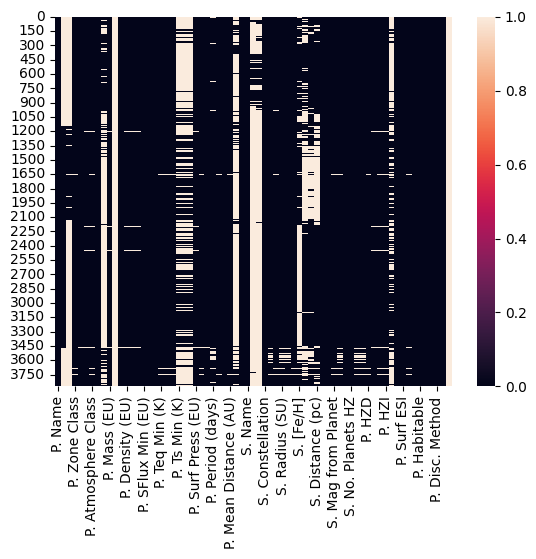

In [202]:
# Graph to clearly see Missing values
sns.heatmap(df.isnull())
plt.show()

In [203]:
# Columns containing more missing values than actual available values were automatically identified and removed to improve overall dataset quality and reduce unnecessary noise.
for i in df.select_dtypes(include=['str','float64','int64']).columns:
     if df[i].isnull().sum() >= df[i].notnull().sum():
         df.drop(columns=i,inplace=True)

#### After

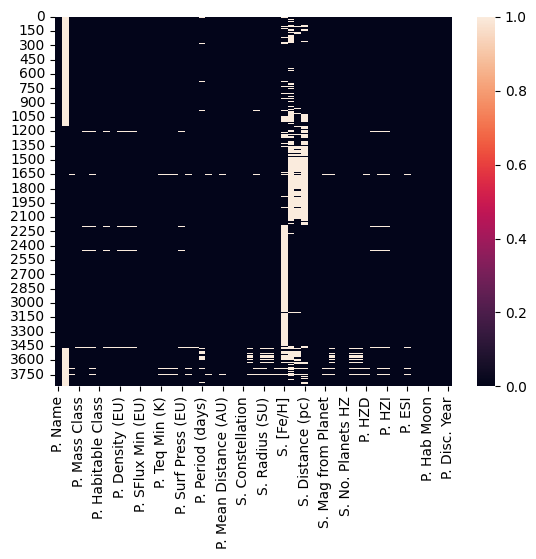

In [204]:
# Graph to clearly see Missing values
sns.heatmap(df.isnull())
plt.show()

In [205]:
# Check Number of columns left
df.shape[1]

58

In [206]:
# We want less Missing values Features & Drop Features of Missing values.
for i in df.select_dtypes(include=['str','float64','int64']).columns:
     if df[i].isnull().sum() > 20:
         df.drop(columns=i,inplace=True)

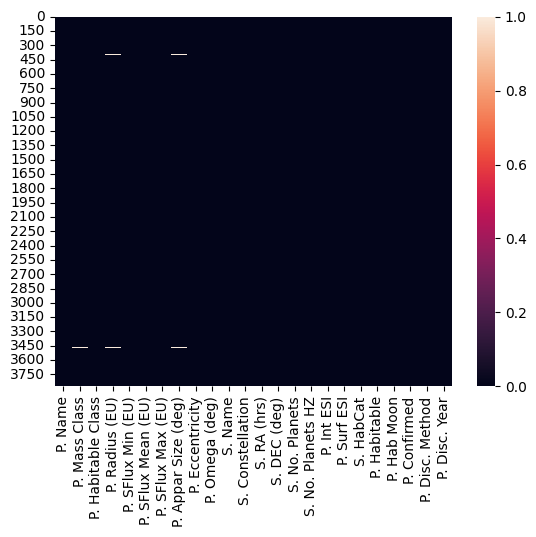

In [207]:
# Graph to clearly see Missing values
sns.heatmap(df.isnull())
plt.show()

In [208]:
df.shape

(3875, 24)

In [209]:
# Check Remaining Missing values
df.isnull().sum()

P. Name                 0
P. Mass Class           6
P. Habitable Class      0
P. Radius (EU)         12
P. SFlux Min (EU)       0
P. SFlux Mean (EU)      0
P. SFlux Max (EU)       0
P. Appar Size (deg)    12
P. Eccentricity         0
P. Omega (deg)          0
S. Name                 0
S. Constellation        0
S. RA (hrs)             0
S. DEC (deg)            0
S. No. Planets          0
S. No. Planets HZ       0
P. Int ESI              0
P. Surf ESI             0
S. HabCat               0
P. Habitable            0
P. Hab Moon             0
P. Confirmed            0
P. Disc. Method         0
P. Disc. Year           0
dtype: int64

In [210]:
df.columns

Index(['P. Name', 'P. Mass Class', 'P. Habitable Class', 'P. Radius (EU)',
       'P. SFlux Min (EU)', 'P. SFlux Mean (EU)', 'P. SFlux Max (EU)',
       'P. Appar Size (deg)', 'P. Eccentricity', 'P. Omega (deg)', 'S. Name',
       'S. Constellation', 'S. RA (hrs)', 'S. DEC (deg)', 'S. No. Planets',
       'S. No. Planets HZ', 'P. Int ESI', 'P. Surf ESI', 'S. HabCat',
       'P. Habitable', 'P. Hab Moon', 'P. Confirmed', 'P. Disc. Method',
       'P. Disc. Year'],
      dtype='str')

#### Filling the Missing Values

In [211]:
df['P. Mass Class'] = df['P. Mass Class'].fillna(df['P. Mass Class'].mode()[0])
df['P. Radius (EU)'] = df['P. Radius (EU)'].fillna(df['P. Radius (EU)'].mean())
df['P. Appar Size (deg)'] = df['P. Appar Size (deg)'].fillna(df['P. Appar Size (deg)'].mean())

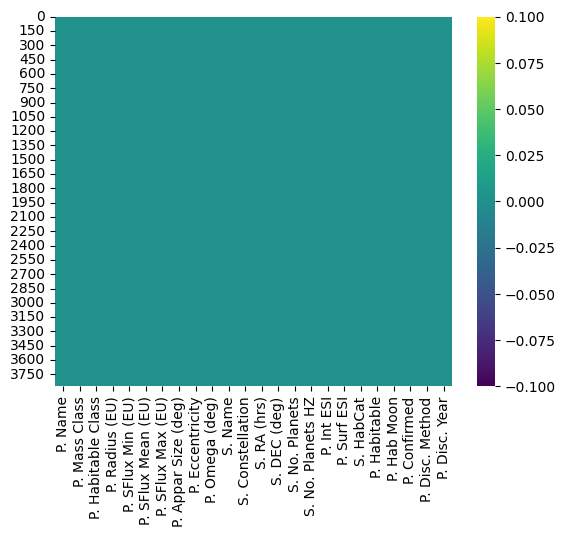

In [212]:
# Graph to clearly see Missing values
sns.heatmap(df.isnull(),cmap='viridis')
plt.show()

In [213]:
# Check Duplication
df.duplicated().sum()

np.int64(0)

### Step 4: Encoding of Dataset

In [214]:
# Apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df.columns:
      df[i] = le.fit_transform(df[i])

In [215]:
df.head(10)

,P. Name,P. Mass Class,P. Habitable Class,P. Radius (EU),P. SFlux Min (EU),P. SFlux Mean (EU),P. SFlux Max (EU),P. Appar Size (deg),P. Eccentricity,P. Omega (deg),...,S. No. Planets,S. No. Planets HZ,P. Int ESI,P. Surf ESI,S. HabCat,P. Habitable,P. Hab Moon,P. Confirmed,P. Disc. Method,P. Disc. Year
0,7,0,2,953,2557,2528,2506,1158,0,0,...,0,0,0,0,0,0,0,1,1,17
1,8,0,2,694,134,114,104,853,0,0,...,0,0,0,0,0,0,0,1,4,21
2,12,0,2,733,2230,2204,2169,915,0,0,...,0,0,0,0,0,0,0,1,1,22
3,13,0,2,714,491,445,382,886,0,0,...,0,0,0,0,0,0,0,1,1,22
4,14,0,2,905,1590,1549,1494,1110,0,0,...,0,0,0,0,0,0,0,1,1,24
5,15,0,2,759,527,481,424,961,0,0,...,0,0,0,0,0,0,0,1,1,19
6,16,0,2,688,3677,1544,3340,844,49,525,...,0,0,0,0,0,0,0,1,1,19
7,17,0,2,759,1629,1588,1536,961,0,0,...,0,0,0,0,0,0,0,1,1,13
8,18,0,2,715,270,223,189,887,0,0,...,0,0,0,0,0,0,0,1,5,24
9,19,0,2,644,528,1525,2149,787,26,330,...,0,0,0,0,0,0,0,1,1,19


### Step 5: Normalization

In [216]:
# Balance the Features for better results
from sklearn.preprocessing import MinMaxScaler
m = MinMaxScaler()
for i in df.columns:
         df[i] = m.fit_transform(df[[i]])

In [217]:
df.head(10)

,P. Name,P. Mass Class,P. Habitable Class,P. Radius (EU),P. SFlux Min (EU),P. SFlux Mean (EU),P. SFlux Max (EU),P. Appar Size (deg),P. Eccentricity,P. Omega (deg),...,S. No. Planets,S. No. Planets HZ,P. Int ESI,P. Surf ESI,S. HabCat,P. Habitable,P. Hab Moon,P. Confirmed,P. Disc. Method,P. Disc. Year
0,0.001807,0.0,0.5,0.977436,0.668846,0.661434,0.655506,0.981356,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.629630
1,0.002065,0.0,0.5,0.711795,0.035051,0.029827,0.027204,0.722881,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.4,0.777778
2,0.003098,0.0,0.5,0.751795,0.583312,0.576661,0.567355,0.775424,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.814815
3,0.003356,0.0,0.5,0.732308,0.128433,0.116431,0.099922,0.750847,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.814815
4,0.003614,0.0,0.5,0.928205,0.415904,0.405285,0.390793,0.940678,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.888889
5,0.003872,0.0,0.5,0.778462,0.137850,0.125850,0.110908,0.814407,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.703704
6,0.004130,0.0,0.5,0.705641,0.961810,0.403977,0.873659,0.715254,0.556818,0.970425,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.703704
7,0.004388,0.0,0.5,0.778462,0.426105,0.415489,0.401779,0.814407,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.481481
8,0.004646,0.0,0.5,0.733333,0.070625,0.058346,0.049438,0.751695,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.888889
9,0.004904,0.0,0.5,0.660513,0.138111,0.399006,0.562124,0.666949,0.295455,0.609982,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.703704


### Step 6: Scatter plot

In [218]:
df['P. Habitable Class'].unique()

array([0.5 , 0.75, 0.25, 1.  , 0.  ])

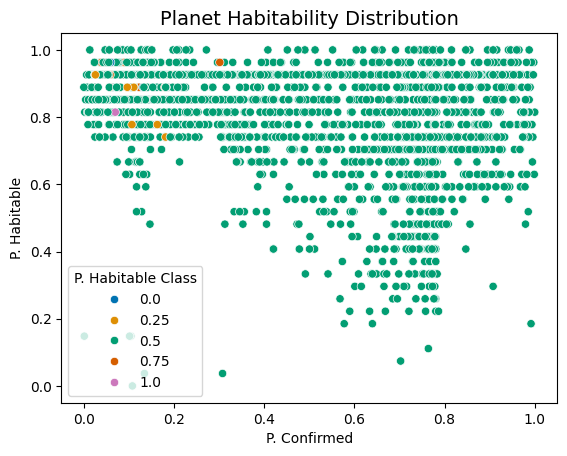

In [219]:
X = df['P. Radius (EU)']
y = df['P. Disc. Year']
sns.scatterplot(data=df,x=X,y=y,hue='P. Habitable Class',palette='colorblind')
plt.title("Planet Habitability Distribution", fontsize=14)
plt.xlabel('P. Confirmed')
plt.ylabel('P. Habitable')
plt.show()

### Step 7: Apply Model

In [220]:
from sklearn.cluster import KMeans
k = KMeans(n_clusters=2,random_state=42)
k.fit(df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [221]:
df['Cluster'] = k.predict(df)

In [223]:
df.head()

,P. Name,P. Mass Class,P. Habitable Class,P. Radius (EU),P. SFlux Min (EU),P. SFlux Mean (EU),P. SFlux Max (EU),P. Appar Size (deg),P. Eccentricity,P. Omega (deg),...,S. No. Planets HZ,P. Int ESI,P. Surf ESI,S. HabCat,P. Habitable,P. Hab Moon,P. Confirmed,P. Disc. Method,P. Disc. Year,Cluster
0,0.001807,0.0,0.5,0.977436,0.668846,0.661434,0.655506,0.981356,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.629630,1
1,0.002065,0.0,0.5,0.711795,0.035051,0.029827,0.027204,0.722881,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.4,0.777778,1
2,0.003098,0.0,0.5,0.751795,0.583312,0.576661,0.567355,0.775424,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.814815,1
3,0.003356,0.0,0.5,0.732308,0.128433,0.116431,0.099922,0.750847,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.814815,1
4,0.003614,0.0,0.5,0.928205,0.415904,0.405285,0.390793,0.940678,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1,0.888889,1


In [224]:
df['Cluster'].value_counts()

Cluster
0    2483
1    1392
Name: count, dtype: int64

### Step 8: Visualization

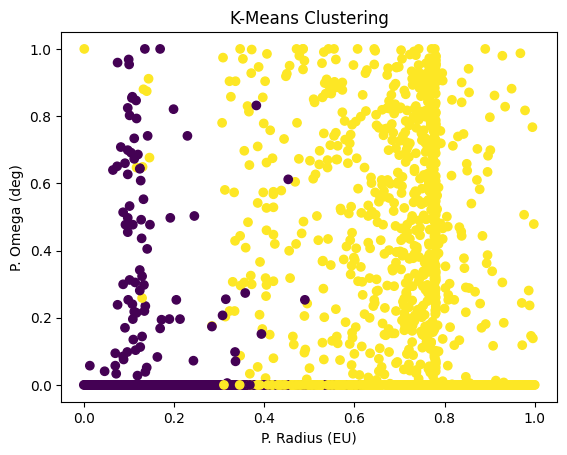

In [226]:
# 2 Features Graph
plt.scatter(df.iloc[:,3],df.iloc[:,9], c=df['Cluster'],cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("P. Radius (EU)")
plt.ylabel("P. Omega (deg)")
plt.show()

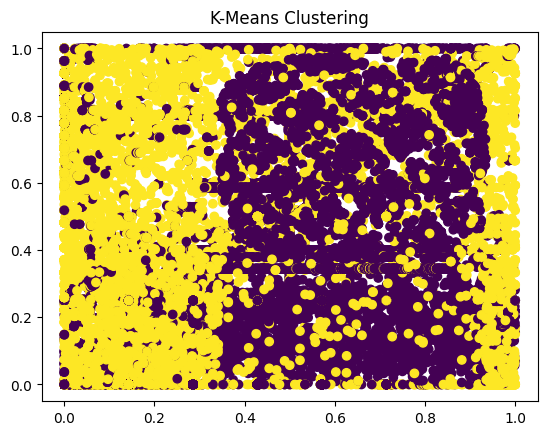

In [227]:
# All Features Graph at once
plt.scatter(df.iloc[:,0],df.iloc[:,1], c=df['Cluster'],cmap='viridis')
plt.scatter(df.iloc[:,2],df.iloc[:,3], c=df['Cluster'],cmap='viridis')
plt.scatter(df.iloc[:,4],df.iloc[:,5], c=df['Cluster'],cmap='viridis')
plt.scatter(df.iloc[:,6],df.iloc[:,7], c=df['Cluster'],cmap='viridis')
plt.scatter(df.iloc[:,8],df.iloc[:,9], c=df['Cluster'],cmap='viridis')
plt.scatter(df.iloc[:,10],df.iloc[:,11], c=df['Cluster'],cmap='viridis')
plt.scatter(df.iloc[:,12],df.iloc[:,13], c=df['Cluster'],cmap='viridis')
plt.scatter(df.iloc[:,14],df.iloc[:,15], c=df['Cluster'],cmap='viridis')
plt.scatter(df.iloc[:,16],df.iloc[:,17], c=df['Cluster'],cmap='viridis')
plt.scatter(df.iloc[:,20],df.iloc[:,23], c=df['Cluster'],cmap='viridis')
plt.title("K-Means Clustering")
plt.show()

Instead of visualizing only one pair of features, multiple feature-pair scatter plots were manually implemented using separate plotting code to explore clustering behavior across many dimensions of the dataset.